In [1]:
import pytbl
import panel
import pandas as pd
import warnings
import numpy as np
from datetime import datetime
from tqdm import tqdm
from joblib import Parallel, delayed
from concurrent.futures import ThreadPoolExecutor
from IPython import get_ipython
from IPython.display import display, Javascript
from IPython import get_ipython
from IPython import get_ipython
ip = get_ipython()
path = None
if '__vsc_ipynb_file__' in ip.user_ns:
    path = ip.user_ns['__vsc_ipynb_file__']
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
warnings.filterwarnings("ignore")
begDate    = "20200130"
endData    = "20201123"
sampleDate = "20210421"

from busdates import PortableBusDates
from tqdm import tqdm
pbd = PortableBusDates()
tradingdays = pbd.get_range(begDate, endData)
nodatelist = pbd.get_range("20201123", "20210421")
preface_tradingdays = pbd.get_range(pbd.prev_date(begDate, 122), begDate) + tradingdays
alpha_name = path.split('.')[0].split('/')[-1]

In [2]:
# root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
# sample_1min_df = pytbl.tbl_read(f"{root_dir}{alpha_name}/{20250401}.tbl")
# sample_1min_df['timeHMSf'] = sample_1min_df['rec_epoch'].apply(lambda timestamp: datetime.fromtimestamp(timestamp).strftime("%H:%M:%S.%f"))
# sample_1min_df.set_index(['sid','timeHMSf'], inplace=True)
# sample_1min_df.sort_index().head(200)

In [3]:
import os

# 定义文件夹路径和目标后缀
folder_path = f'./{alpha_name}/'
target_suffix = '.sdiv'

# 获取文件夹中的所有文件名
files = os.listdir(folder_path)

# 筛选出符合目标后缀的文件名，并提取日期部分
date_list = []
for file in files:
    if file.endswith(target_suffix):
        # 假设文件名格式为 "date.terms.xxxxxxxx.sdiv"，提取日期部分
        date = file.split('.')[1]  # 提取文件名中的日期部分
        date_list.append(date)

# 输出日期列表
print(date_list)

['20201012', '20220118', '20210610', '20210802', '20200526', '20200610', '20200219', '20200611', '20201016', '20220117', '20220223', '20210707', '20200310', '20200414', '20200506', '20211125', '20211227', '20210520', '20200401', '20211011', '20210630', '20220107', '20220307', '20200806', '20220222', '20200210', '20200724', '20200717', '20211222', '20200206', '20200319', '20211213', '20210810', '20200807', '20200911', '20210608', '20210430', '20211124', '20200710', '20210512', '20220215', '20210609', '20200514', '20211014', '20200916', '20211201', '20200511', '20200624', '20200306', '20210902', '20200601', '20200914', '20200522', '20220310', '20211228', '20211229', '20211029', '20200805', '20210721', '20210908', '20200428', '20200618', '20200608', '20210813', '20210804', '20200615', '20210526', '20220126', '20210730', '20211105', '20211206', '20200421', '20210803', '20200818', '20210729', '20211230', '20210819', '20200729', '20210723', '20200630', '20200716', '20201106', '20220207', '20

In [4]:
# sampleDate = "20240409"
root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
def loadingfeaturetbl(sampleDate, alpha_name):
    # sample_1min_df = pytbl.tbl_read(f"{root_dir}demo_3/{sampleDate}.tbl")
    if sampleDate not in date_list:
        return
    sample_1min_df = panel.sdiv2df(
        panel.read(f"{root_dir}{alpha_name}/terms.{sampleDate}.sdiv")
    )
    return sample_1min_df


Process_1min_df = Parallel(n_jobs=100, verbose=10)(
    delayed(loadingfeaturetbl)(sampleDate, alpha_name) for sampleDate in tqdm(tradingdays)
)
Process_1min_df = [Pro for Pro in Process_1min_df if Pro is not None]
feature_1min_df = pd.concat(Process_1min_df, ignore_index=True)
feature_1min_df = feature_1min_df.reset_index()
feature_1min_df['sid'] = feature_1min_df['sid'].astype(int).astype(str)
feature_1min_df = feature_1min_df.set_index(['sid','date','time']).sort_index()

100%|██████████| 199/199 [00:01<00:00, 144.51it/s]
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    5.1s
[Parallel(n_jobs=100)]: Done  20 out of 199 | elapsed:    5.6s remaining:   50.0s
[Parallel(n_jobs=100)]: Done  40 out of 199 | elapsed:    6.1s remaining:   24.1s
[Parallel(n_jobs=100)]: Done  60 out of 199 | elapsed:    6.6s remaining:   15.2s
[Parallel(n_jobs=100)]: Done  80 out of 199 | elapsed:    7.0s remaining:   10.4s
[Parallel(n_jobs=100)]: Done 100 out of 199 | elapsed:    7.4s remaining:    7.3s
[Parallel(n_jobs=100)]: Done 120 out of 199 | elapsed:    7.8s remaining:    5.1s
[Parallel(n_jobs=100)]: Done 140 out of 199 | elapsed:    8.2s remaining:    3.5s
[Parallel(n_jobs=100)]: Done 160 out of 199 | elapsed:    8.6s remaining:    2.1s
[Parallel(n_jobs=100)]: Done 180 out of 199 | elapsed:    8.9s remaining:    0.9s
[Parallel(n_jobs=100)]: Done 199 out of 199 | elapsed:    9.3s finished


In [5]:
# univ = 'midx'
# label_dir = '/data/beer2/data/CA.LTS/CNEQ/Panels/'
# def load_labels_1min(sampleDate, univ):
#     Omin_label = panel.sdiv2df(
#         panel.read(f"{label_dir}Y/Y_v5_1min/terms.{sampleDate}.sdiv").sel(V=slice('ret1h','ret0e'))
#     )
#     active = panel.sdiv2df(
#         panel.read(f"{label_dir}I/fq1m/BB/terms.{sampleDate}.sdiv").sel(V=slice('is.active','is.active'))
#     )
#     univ = panel.sdiv2df(
#         panel.read(f"{label_dir}D/bod/univ/univ-{sampleDate}.sdiv").sel(V=slice(f"{univ}", f"{univ}"))
#     )
#     return Omin_label, active, univ
# Process_label_df = Parallel(n_jobs=100, verbose=10)(
#     delayed(load_labels_1min)(sampleDate, univ) for sampleDate in tqdm(tradingdays)
# )
# label_df  = pd.concat([Process[0] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# weight_df = pd.concat([Process[1] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# univ_df   = pd.concat([Process[2] for Process in Process_label_df], ignore_index=True).set_index(['sid','date'])

# label_df = label_df.merge(weight_df[['is.active']], left_index=True, right_index=True, how='left')
# label_df = label_df.merge(univ_df, left_index=True, right_index=True, how='left')
# label_df = label_df[label_df[f'{univ}']>0]

# label_df['ret0e_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret0e'].shift(-1)
# label_df['ret1h_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret1h'].shift(-1)
# label_df.to_parquet("/data/nfshome/wensheng/git/wensheng_jawN9J/label_df.parquet", engine="pyarrow", compression="snappy")

In [6]:
label_df = pd.read_feather("/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/label_df_2020_202011.feather")
feature_1min_df[f'buysellQtySumPos_divall'] = (feature_1min_df[f'QtySumPos']) / (feature_1min_df['Qtytrans_all']) 
feature_1min_df[f'buyallQtySumPosshare_divall'] = (feature_1min_df[f'buyShareSumPos'] + feature_1min_df[f'QtySumPos'] ) / (feature_1min_df['Qtytrans_all']) 
feature_1min_df[f'sellallQtySumPosshare_divall'] = (feature_1min_df[f'sellShareSumPos'] + feature_1min_df[f'QtySumPos'] ) / (feature_1min_df['Qtytrans_all']) 
feature_1min_df[f'buysellQtySumNeg_divall'] = (feature_1min_df[f'QtySumNeg']) / (feature_1min_df['Qtytrans_all']) 
feature_1min_df[f'buyallQtySumNegshare_divall'] = (feature_1min_df[f'buyShareSumNeg'] + feature_1min_df[f'QtySumNeg'] ) / (feature_1min_df['Qtytrans_all']) 
feature_1min_df[f'sellallQtySumNegshare_divall'] = (feature_1min_df[f'sellShareSumNeg'] + feature_1min_df[f'QtySumNeg'] ) / (feature_1min_df['Qtytrans_all']) 



feature_1min_df[f'CountBSratioPos'] = (feature_1min_df[f'buyOidCountPos'] - feature_1min_df[f'sellOidCountPos'] ) / (feature_1min_df['buyOidCountPos'] + feature_1min_df['sellOidCountPos']) 
feature_1min_df[f'CountBSPos'] = (feature_1min_df[f'buyOidCountPos'] - feature_1min_df[f'sellOidCountPos'] ) / feature_1min_df['NumSum']
feature_1min_df[f'CountBSratioNeg'] = (feature_1min_df[f'buyOidCountNeg'] - feature_1min_df[f'sellOidCountNeg'] ) / (feature_1min_df['buyOidCountNeg'] + feature_1min_df['sellOidCountNeg']) 
feature_1min_df[f'CountBSNeg'] = (feature_1min_df[f'buyOidCountNeg'] - feature_1min_df[f'sellOidCountNeg'] ) / feature_1min_df['NumSum']

In [7]:
feature_all_df = feature_1min_df.merge(label_df[['ret1h','ret0e','is.active','ret0e_shift','ret1h_shift']], left_index=True, right_index=True, how='inner')
feature_all_df = feature_all_df[(feature_all_df['is.active']>0)]


In [10]:
# feature_all_df.describe()

feature_all_df = feature_all_df.replace(0.0, np.nan)
feature_all_df = feature_all_df.replace(np.inf, np.nan).replace(-np.inf, np.nan)

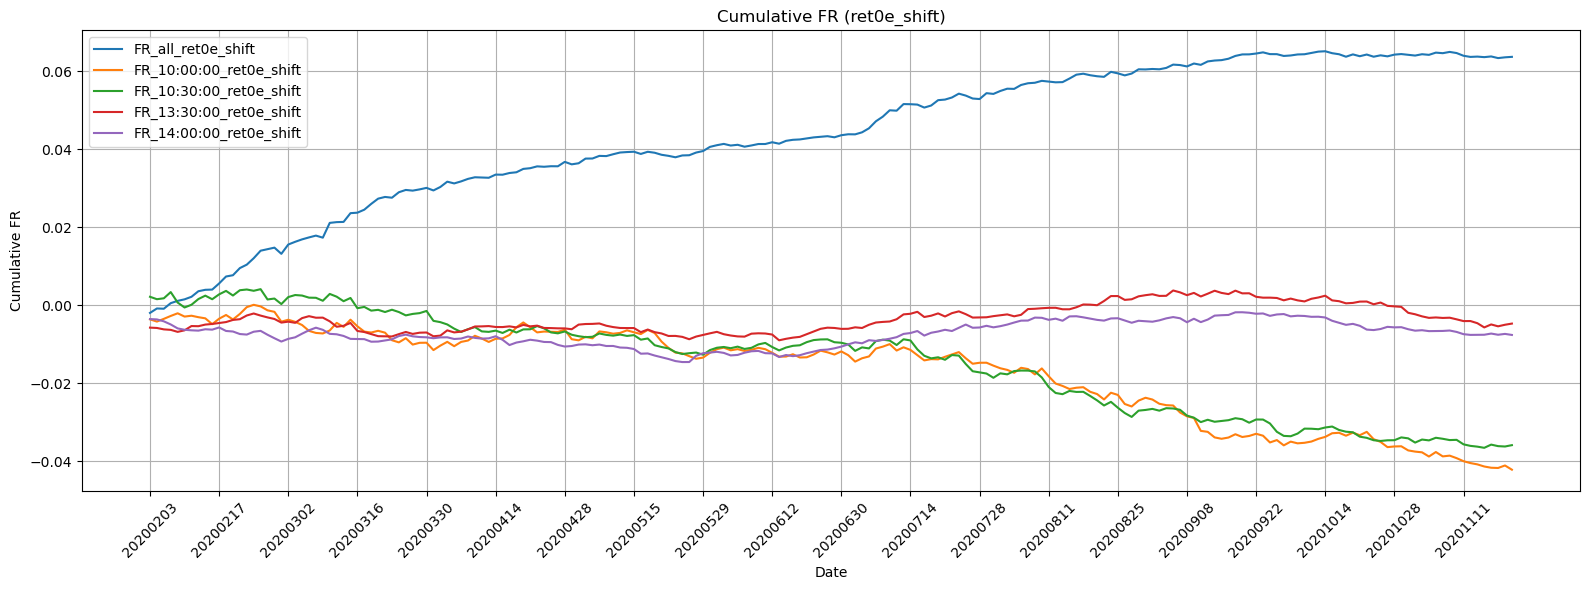

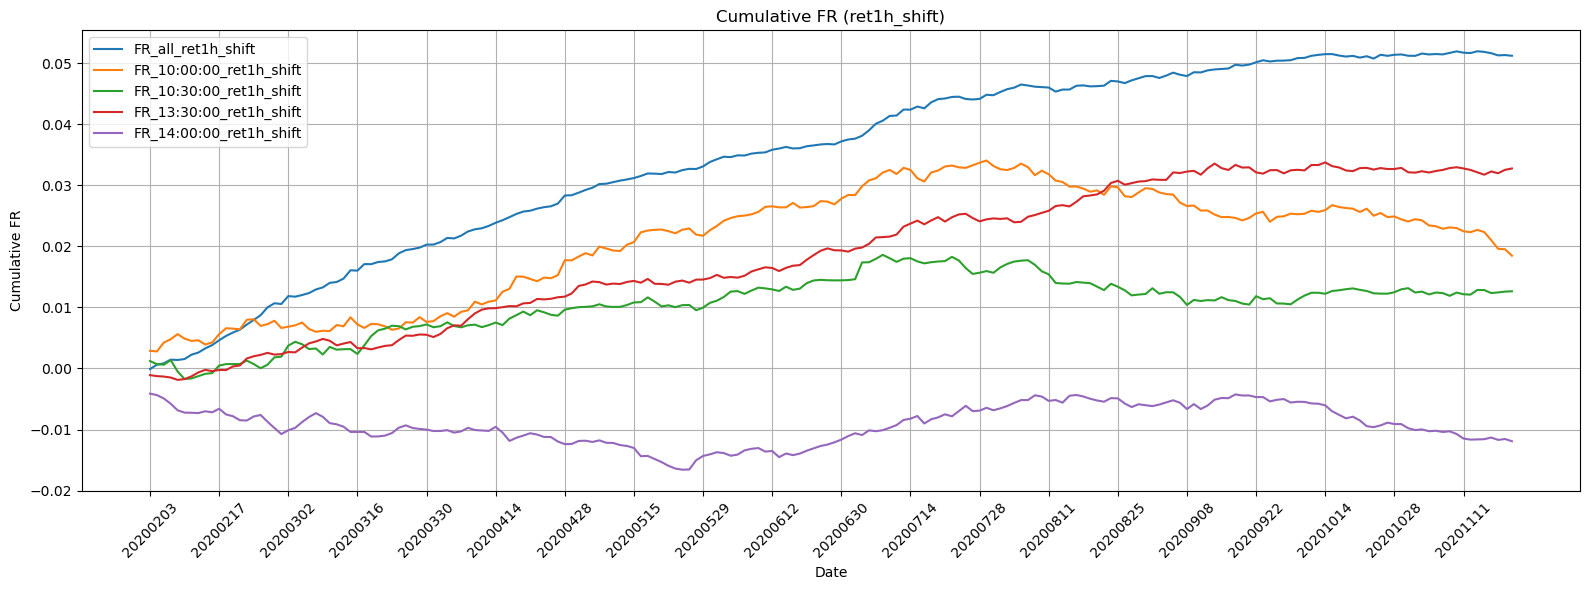

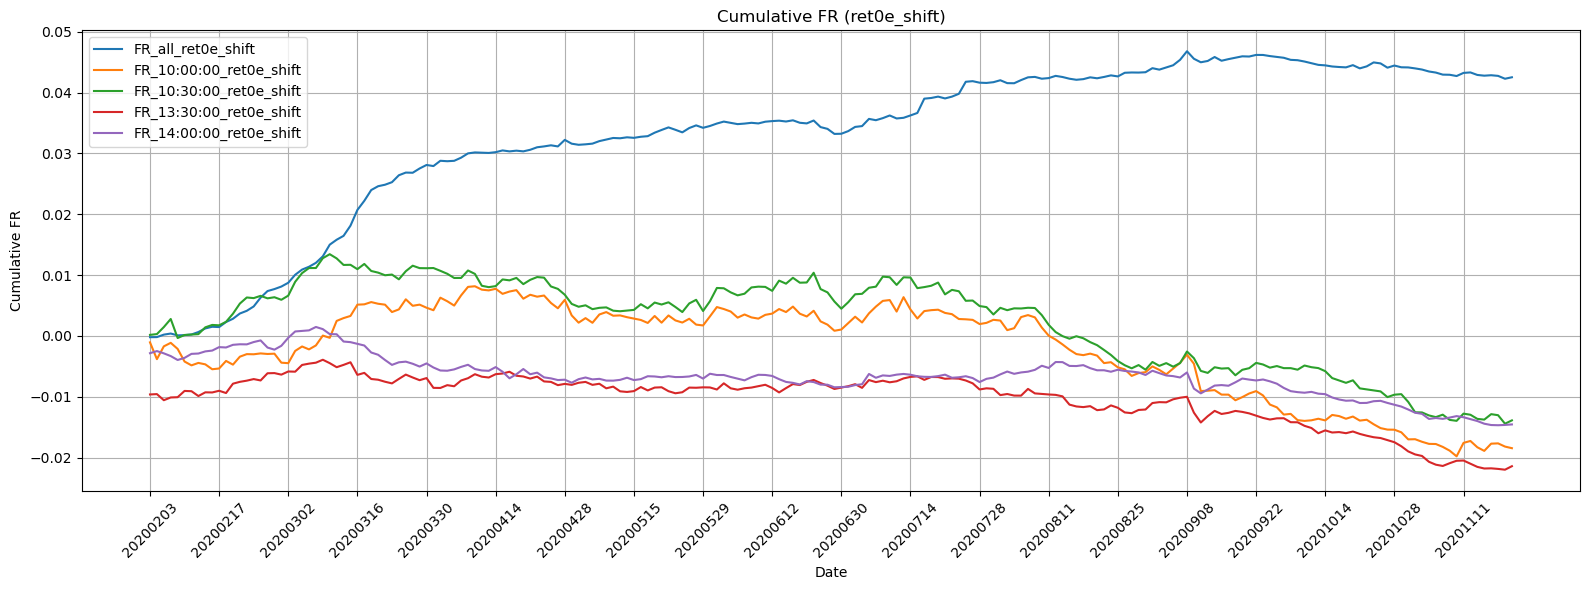

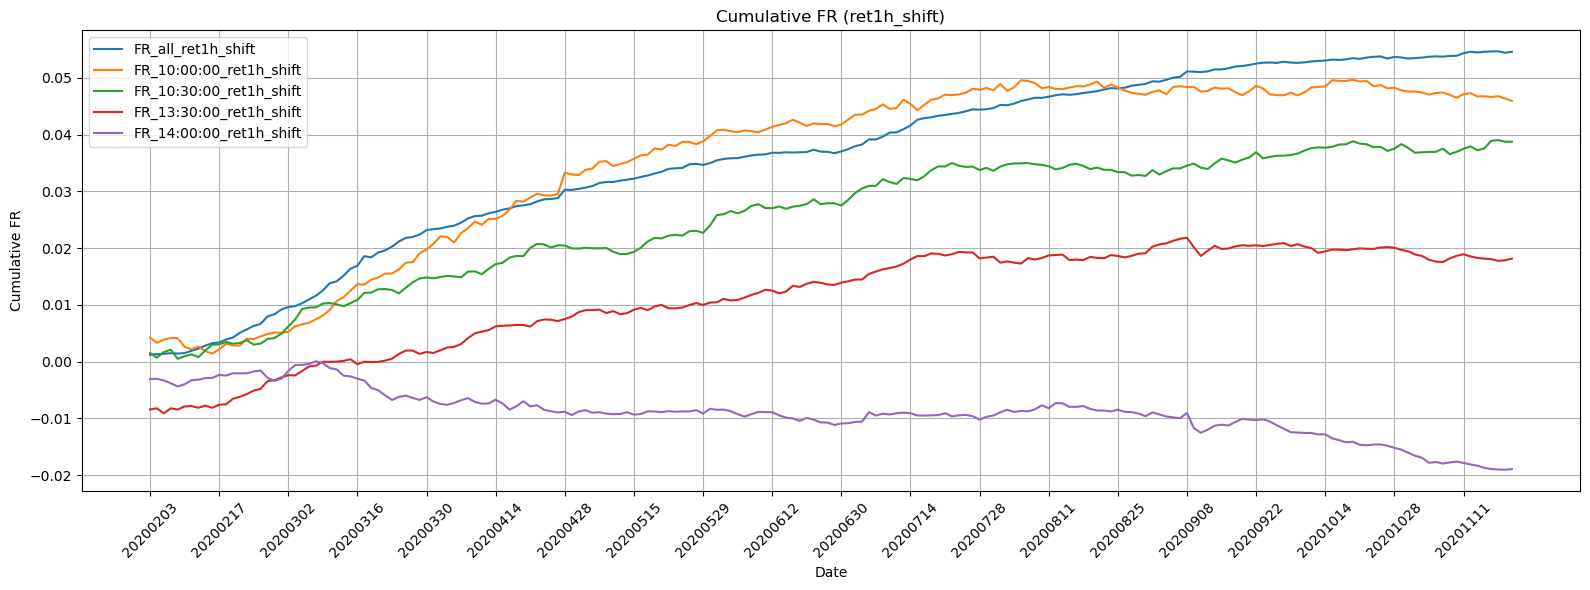

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_cols(feat_col):
    # # 假设你已经有以下变量
    # feat_col = 'Around3s_AvgPrc_minusclose'
    ret_cols = ['ret0e_shift', 'ret1h_shift']
    time_points = ['10:00:00', '10:30:00', '13:30:00', '14:00:00']

    df = feature_all_df.reset_index()

    # ---------- 全部时间点 (FR_all_*) ----------
    fr_all_results = {}
    for ret_col in ret_cols:
        sub_df = df[[feat_col, ret_col, 'date']].dropna()

        # 按date groupby，计算 FR = cov(x, y) / std(x)
        grouped = sub_df.groupby('date')
        mean_x = grouped[feat_col].transform('mean')
        mean_y = grouped[ret_col].transform('mean')
        std_x = grouped[feat_col].transform('std')

        cov_xy = ((sub_df[feat_col] - mean_x) * (sub_df[ret_col] - mean_y)).groupby(sub_df['date']).mean()
        std_x_daily = std_x.groupby(sub_df['date']).first()  # std(x)是一样的，随便取一个就行

        fr = cov_xy / std_x_daily.replace(0, np.nan)
        fr_all_results[f'FR_all_{ret_col}'] = fr

    # ---------- 特定时间点 (FR_{time}_{ret_col}) ----------
    fr_time_results = {}

    for tp in time_points:
        df_tp = df[df['time'] == tp].dropna(subset=[feat_col] + ret_cols)
        for ret_col in ret_cols:
            grouped = df_tp.groupby('date')
            x = df_tp[feat_col]
            y = df_tp[ret_col]
            mean_x = grouped[feat_col].transform('mean')
            mean_y = grouped[ret_col].transform('mean')
            std_x = grouped[feat_col].transform('std')

            cov_xy = ((x - mean_x) * (y - mean_y)).groupby(df_tp['date']).mean()
            std_x_daily = std_x.groupby(df_tp['date']).first()

            fr = cov_xy / std_x_daily.replace(0, np.nan)
            fr_time_results[f'FR_{tp}_{ret_col}'] = fr

    # 合并所有结果
    fr_all_df = pd.DataFrame(fr_all_results)
    fr_time_df = pd.DataFrame(fr_time_results)
    fr_df = pd.concat([fr_all_df, fr_time_df], axis=1)

    # 计算 cumulative FR
    cumulative_fr_df = fr_df.cumsum()


    # 分别提取 ret0e 和 ret1h 的 FR 列
    fr_0e_cols = [col for col in cumulative_fr_df.columns if 'ret0e_shift' in col]
    fr_1h_cols = [col for col in cumulative_fr_df.columns if 'ret1h_shift' in col]

    # 画 ret0e_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_0e_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title('Cumulative FR (ret0e_shift)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()

    # 画 ret1h_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_1h_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title('Cumulative FR (ret1h_shift)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()
    fr_df.to_parquet(f'/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/fr_save/{feat_col}.parquet', engine="pyarrow", compression="snappy")
    
for feat_col in [ 'CountBSratioPos','CountBSratioNeg']:
    plot_cols(feat_col)

In [1]:
import os
import pandas as pd

def compute_fr_correlation(fr_df: pd.DataFrame, folder_path='./fr_save/'):
    target_columns = [
        'FR_all_ret0e_shift',
        'FR_all_ret1h_shift',
        'FR_10:30:00_ret0e_shift',
        'FR_10:30:00_ret1h_shift'
    ]

    records = []

    for filename in os.listdir(folder_path):
        if filename.endswith('.parquet'):
            file_path = os.path.join(folder_path, filename)
            df = pd.read_parquet(file_path)

            # 确保只计算两边都存在的列
            common_cols = [col for col in target_columns if col in df.columns and col in fr_df.columns]

            # 对齐索引
            aligned_fr_df, aligned_df = fr_df[common_cols].align(df[common_cols], join='inner')

            # 计算每列的相关系数
            row = {'filename': filename}
            for col in common_cols:
                row[col] = aligned_fr_df[col].corr(aligned_df[col])
            
            # 添加平均相关性
            row['mean_corr'] = sum(row[col] for col in common_cols) / len(common_cols)
            records.append(row)

    result_df = pd.DataFrame(records)

    # 输出 top5 和 bottom5
    print("Top 5 correlation files:")
    print(result_df.sort_values('mean_corr', ascending=False).head(5))

    print("\nBottom 5 correlation files:")
    print(result_df.sort_values('mean_corr', ascending=True).head(5))

    return result_df
